Random Forest Accuracy: 0.9486
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.76      0.72      0.74        18
           2       0.95      1.00      0.97        18
           3       0.82      1.00      0.90        18
           4       0.86      1.00      0.93        19
           5       0.93      0.72      0.81        18
           6       1.00      1.00      1.00        19
           7       1.00      1.00      1.00        19
           8       1.00      1.00      1.00        18
           9       1.00      1.00      1.00        19
          10       1.00      1.00      1.00        19
          11       1.00      0.94      0.97        18
          12       0.78      0.74      0.76        19
          13       1.00      1.00      1.00        18
          14       0.94      0.89      0.92        19
          15       1.00      1.00      1.00        18
          16       1.00    

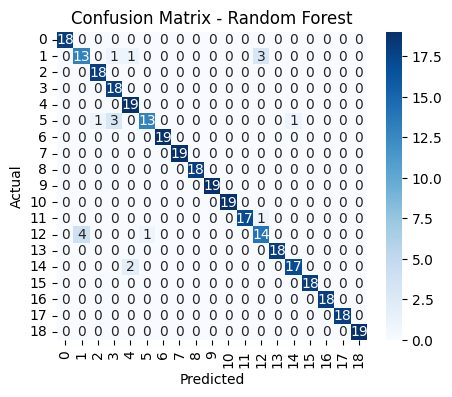

SVM Accuracy: 0.9171
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       0.71      0.56      0.62        18
           2       1.00      1.00      1.00        18
           3       0.79      0.83      0.81        18
           4       0.72      0.95      0.82        19
           5       0.68      0.72      0.70        18
           6       1.00      1.00      1.00        19
           7       1.00      1.00      1.00        19
           8       1.00      1.00      1.00        18
           9       1.00      1.00      1.00        19
          10       1.00      1.00      1.00        19
          11       0.81      0.94      0.87        18
          12       0.92      0.63      0.75        19
          13       0.95      1.00      0.97        18
          14       0.89      0.84      0.86        19
          15       1.00      1.00      1.00        18
          16       1.00      1.00    

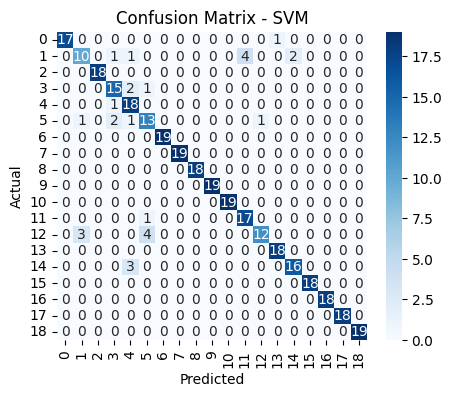

Decision Tree Accuracy: 0.9257
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.83      0.56      0.67        18
           2       1.00      1.00      1.00        18
           3       0.89      0.94      0.92        18
           4       0.84      0.84      0.84        19
           5       0.75      0.83      0.79        18
           6       1.00      1.00      1.00        19
           7       1.00      1.00      1.00        19
           8       0.95      1.00      0.97        18
           9       1.00      1.00      1.00        19
          10       1.00      1.00      1.00        19
          11       0.74      0.78      0.76        18
          12       0.68      0.79      0.73        19
          13       1.00      1.00      1.00        18
          14       0.94      0.84      0.89        19
          15       1.00      1.00      1.00        18
          16       1.00    

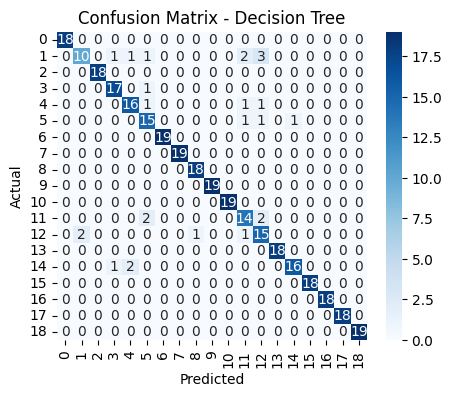

Logistic Regression Accuracy: 0.8743
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.81      0.72      0.76        18
           2       1.00      1.00      1.00        18
           3       0.74      0.78      0.76        18
           4       0.50      0.37      0.42        19
           5       0.67      0.67      0.67        18
           6       1.00      0.79      0.88        19
           7       1.00      1.00      1.00        19
           8       0.95      1.00      0.97        18
           9       1.00      1.00      1.00        19
          10       1.00      1.00      1.00        19
          11       0.70      0.89      0.78        18
          12       0.86      0.63      0.73        19
          13       1.00      1.00      1.00        18
          14       0.62      0.79      0.70        19
          15       0.82      1.00      0.90        18
          16       1.

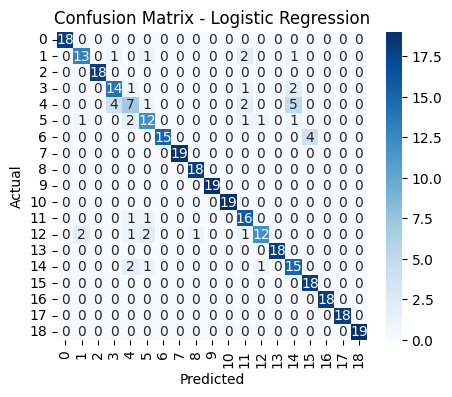


Tuning Hyperparameters for Random Forest...
Best Parameters for Random Forest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

Tuning Hyperparameters for SVM...
Best Parameters for SVM: {'C': 10, 'kernel': 'rbf'}

Tuning Hyperparameters for Decision Tree...
Best Parameters for Decision Tree: {'max_depth': None, 'min_samples_split': 2}

Tuning Hyperparameters for Logistic Regression...
Best Parameters for Logistic Regression: {'C': 10, 'solver': 'lbfgs'}


In [ ]:
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Processed Data
file_path = "/mnt/data/processed_data.pkl"
with open(file_path, "rb") as file:
    final_df = pickle.load(file)

# Define Features and Target
X = final_df.drop(columns=['disease_type'])  # Adjust column name
y = final_df['disease_type']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize models with default parameters
models = {
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression()
}

# Function to evaluate models
def train_and_evaluate_model(model, name):
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Accuracy Scores
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    print(f"{name} -> Training Accuracy: {train_acc:.4f}, Testing Accuracy: {test_acc:.4f}")
    print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")

    # Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    
    return train_acc, test_acc

# Train and evaluate each model
model_accuracies = {}
for name, model in models.items():
    train_acc, test_acc = train_and_evaluate_model(model, name)
    model_accuracies[name] = (train_acc, test_acc)

# Hyperparameter Tuning using GridSearchCV
param_grid = {
    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
    },
    "Decision Tree": {
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
    },
    "Logistic Regression": {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs", "liblinear"],
    },
}

# Automatically detect best parameters
best_models = {}
for name, model in models.items():
    print(f"\n🔍 Tuning Hyperparameters for {name}...")
    grid_search = GridSearchCV(model, param_grid[name], cv=5, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    print(f"✅ Best Parameters for {name}: {grid_search.best_params_}")

# Evaluate Best Models
best_model_accuracies = {}
for name, model in best_models.items():
    train_acc, test_acc = train_and_evaluate_model(model, name)
    best_model_accuracies[name] = (train_acc, test_acc)

# Determine Best Model Based on Test Accuracy
best_model_name = max(best_model_accuracies, key=lambda name: best_model_accuracies[name][1])
best_model = best_models[best_model_name]